# LSTM Algorithm Motivation

After implementing statistical models such as SARIMA and SARIMAX, and machine learning models such as Random Forest and XGBoost, the next step is to evaluate a deep learning model specifically designed for sequential data.

Long Short-Term Memory (LSTM) is a type of recurrent neural network (RNN) that is capable of learning temporal dependencies over time. Unlike traditional machine learning algorithms, LSTM can directly model sequential patterns without relying entirely on manually engineered lag relationships.

In the context of maritime container throughput forecasting, the target variable exhibits time dependence, seasonality, and nonlinear variation. LSTM is particularly suitable for such problems because it is designed to retain information from previous time steps and use it to predict future values.

Therefore, LSTM is implemented in this study to evaluate whether a deep learning approach can improve forecasting accuracy compared to statistical and tree-based machine learning models.

# Theoretical Background of LSTM

Long Short-Term Memory (LSTM) is a special type of recurrent neural network (RNN) designed to model sequential and time-dependent data.

Traditional RNNs suffer from the vanishing gradient problem, which makes them less effective for learning long-term dependencies. LSTM addresses this problem by introducing a memory cell and gating mechanisms.

An LSTM unit contains:

- a forget gate
- an input gate
- an output gate
- a cell state

These gates control what information is:

- removed from memory
- added to memory
- passed to the output

This allows the LSTM network to retain useful information over longer sequences.

In time-series forecasting, LSTM can learn relationships between past and future observations directly from the sequence data, making it suitable for capturing complex temporal patterns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
df = pd.read_excel(r"C:\Users\Lenovo\Downloads\Maritime_data.xlsx")
df.head()

,Date,Monthly Total TEUs,United States_export_constant_us,United States_export_current_us,United States_import_constant_us,United States_import_current_us,United States_Industry_production,Retail_market
0,01/31/2009 12:00:00 AM,587004.20,85294.39,82415.0,145046.7,130644.1,240000000000,97.06544
1,02/28/2009 12:00:00 AM,413910.30,88213.10,84903.0,137453.7,123590.1,239000000000,96.29944
2,03/31/2009 12:00:00 AM,526487.05,87720.89,83500.0,134329.4,120045.8,235000000000,94.70880
3,04/30/2009 12:00:00 AM,532124.15,85022.69,81088.0,135802.4,121256.0,233000000000,95.10927
4,05/31/2009 12:00:00 AM,574827.80,87143.64,83369.0,129079.8,116262.6,231000000000,95.75613


# Data Preprocessing for LSTM

LSTM models require the data to be prepared in a specific sequential format.

The following preprocessing steps are performed:

1. convert the Date column into datetime format
2. set the Date column as the index
3. ensure monthly frequency
4. select the target variable
5. scale the target variable
6. create fixed-length input sequences
7. split the data chronologically into training and testing datasets

Unlike Random Forest and XGBoost, which use lagged tabular features, LSTM uses ordered sequences of observations as input.

In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')
df = df.asfreq('M')

df.head()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27636\1160887746.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27636\1160887746.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df = df.asfreq('M')


,Monthly Total TEUs,United States_export_constant_us,United States_export_current_us,United States_import_constant_us,United States_import_current_us,United States_Industry_production,Retail_market
Date,,,,,,,
2009-01-31,587004.20,85294.39,82415.0,145046.7,130644.1,240000000000,97.06544
2009-02-28,413910.30,88213.10,84903.0,137453.7,123590.1,239000000000,96.29944
2009-03-31,526487.05,87720.89,83500.0,134329.4,120045.8,235000000000,94.70880
2009-04-30,532124.15,85022.69,81088.0,135802.4,121256.0,233000000000,95.10927
2009-05-31,574827.80,87143.64,83369.0,129079.8,116262.6,231000000000,95.75613


# Selecting the Target Variable

In the initial LSTM implementation, only the target variable is used. This allows the deep learning model to learn temporal dependencies directly from the historical container throughput values.

Target Variable:
- Monthly Total TEUs

In [5]:
data = df[['Monthly Total TEUs']].copy()
data.head()

,Monthly Total TEUs
Date,
2009-01-31,587004.20
2009-02-28,413910.30
2009-03-31,526487.05
2009-04-30,532124.15
2009-05-31,574827.80


# Feature Scaling

LSTM models are sensitive to the scale of input data. Therefore, the target variable is normalized using Min-Max scaling.

This transformation scales the values to the range [0, 1], which helps improve convergence during neural network training.

In [6]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Sequence Creation

LSTM models require sequential input data. Therefore, the time series is transformed into fixed-length sequences.

For each prediction, the model uses a specified number of previous observations as input.

In this implementation, the previous 12 months are used to predict the next month. This window size is selected because the dataset has monthly observations and yearly seasonality may be relevant.

In [7]:
def create_sequences(dataset, time_steps=12):
    X, y = [], []
    for i in range(time_steps, len(dataset)):
        X.append(dataset[i-time_steps:i, 0])
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)

In [8]:
time_steps = 12
X, y = create_sequences(scaled_data, time_steps)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (81, 12)
y shape: (81,)


# Reshaping Input Data

LSTM layers require three-dimensional input in the following format:

(samples, time steps, features)

Since this is a univariate sequence model, the number of features is 1.

In [9]:
X = X.reshape((X.shape[0], X.shape[1], 1))
print("Reshaped X shape:", X.shape)

Reshaped X shape: (81, 12, 1)


# Train-Test Split

The sequence data is split chronologically into training and testing sets. This ensures that the model is trained on historical observations and evaluated on future observations.

In [10]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (64, 12, 1)
X_test shape: (17, 12, 1)
y_train shape: (64,)
y_test shape: (17,)


# LSTM Model Implementation

A simple LSTM architecture is implemented to reduce overfitting risk, since the dataset is relatively small.

The model consists of:

- one LSTM layer
- one dropout layer
- one dense output layer

This architecture is sufficient to evaluate whether deep learning can improve forecasting performance for this dataset.

In [11]:
lstm_model = Sequential([
    LSTM(50, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

C:\Users\Lenovo\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

# Model Training

The LSTM model is trained on the training data using Mean Squared Error (MSE) as the loss function.

Early stopping is used to prevent overfitting by stopping training when validation loss no longer improves.

In [12]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [13]:
history = lstm_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=8,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.3667 - val_loss: 0.2295
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0893 - val_loss: 0.0202
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0580 - val_loss: 0.0288
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0446 - val_loss: 0.0287
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0461 - val_loss: 0.0452
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0470 - val_loss: 0.0316
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0482 - val_loss: 0.0208
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0445 - val_loss: 0.0251
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0371 - val_loss: 0.0226
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0455 - val_loss: 0.0270
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0458 - val_loss: 0.0251
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0448 - val_loss: 0.

# Training Loss Visualization

The training and validation loss curves are plotted to assess the learning behavior of the model.

If both curves decrease and remain close to each other, the model is learning effectively. If validation loss increases while training loss decreases, overfitting may be present.

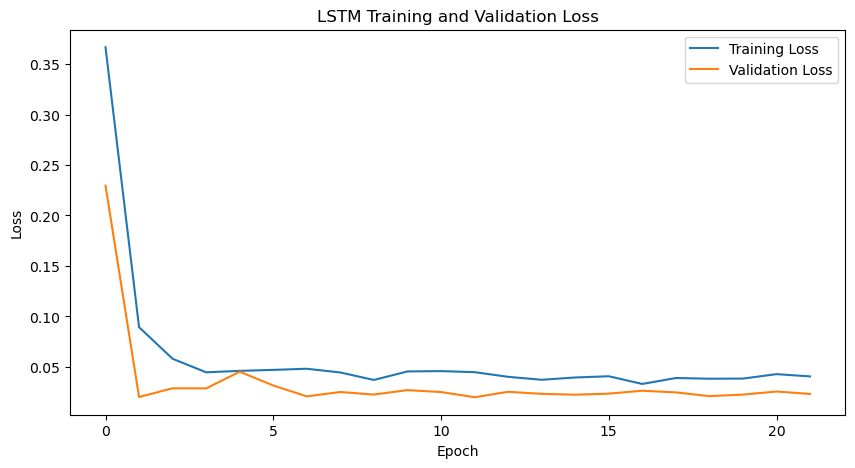

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Forecast Generation

After training, the LSTM model is used to generate predictions for the testing dataset.

Since the model was trained on scaled data, the predictions must be transformed back to the original scale before evaluation.

In [15]:
lstm_predictions_scaled = lstm_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step


In [16]:
lstm_predictions = scaler.inverse_transform(lstm_predictions_scaled.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Model Evaluation

The performance of the LSTM model is evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)

These metrics allow comparison with the previously implemented statistical and machine learning models.

In [17]:
mae_lstm = mean_absolute_error(y_test_actual, lstm_predictions)
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, lstm_predictions))
mape_lstm = np.mean(np.abs((y_test_actual - lstm_predictions) / y_test_actual)) * 100

print("LSTM MAE:", mae_lstm)
print("LSTM RMSE:", rmse_lstm)
print("LSTM MAPE:", mape_lstm)

LSTM MAE: 42548.153676470596
LSTM RMSE: 54390.806909293555
LSTM MAPE: 6.005363359251468


# Forecast Visualization

The actual and predicted values are plotted to visually assess how well the LSTM model follows the test period observations.

In [18]:
test_index = data.index[time_steps + train_size:]

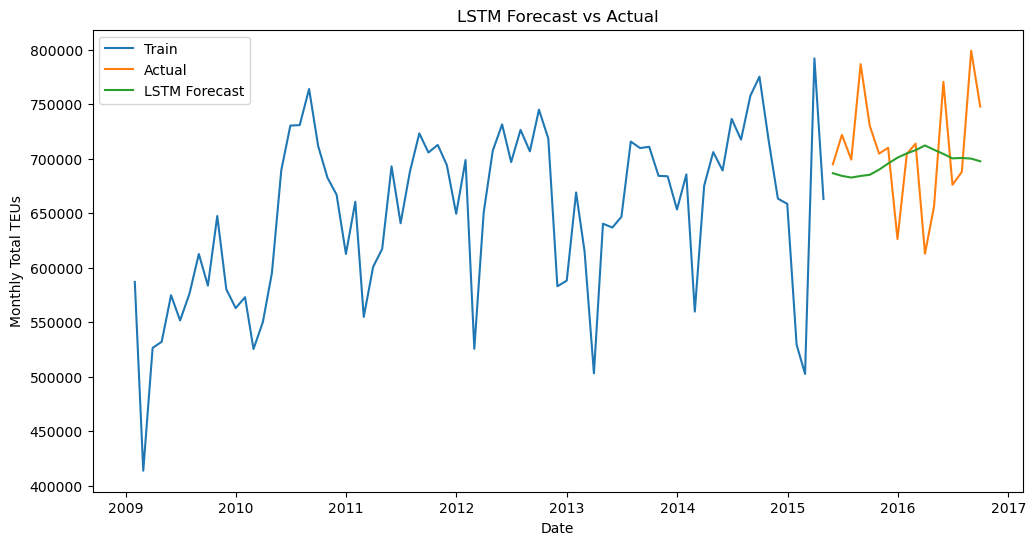

In [19]:
plt.figure(figsize=(12, 6))

plt.plot(data.index[:time_steps + train_size], data['Monthly Total TEUs'][:time_steps + train_size], label='Train')
plt.plot(test_index, y_test_actual.flatten(), label='Actual')
plt.plot(test_index, lstm_predictions.flatten(), label='LSTM Forecast')

plt.title("LSTM Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Monthly Total TEUs")
plt.legend()
plt.show()

# Residual Analysis

Residuals are computed to evaluate the remaining prediction errors of the LSTM model.

If the residuals fluctuate randomly around zero, it suggests that the model has captured most of the systematic patterns in the data.

In [20]:
lstm_residuals = y_test_actual.flatten() - lstm_predictions.flatten()

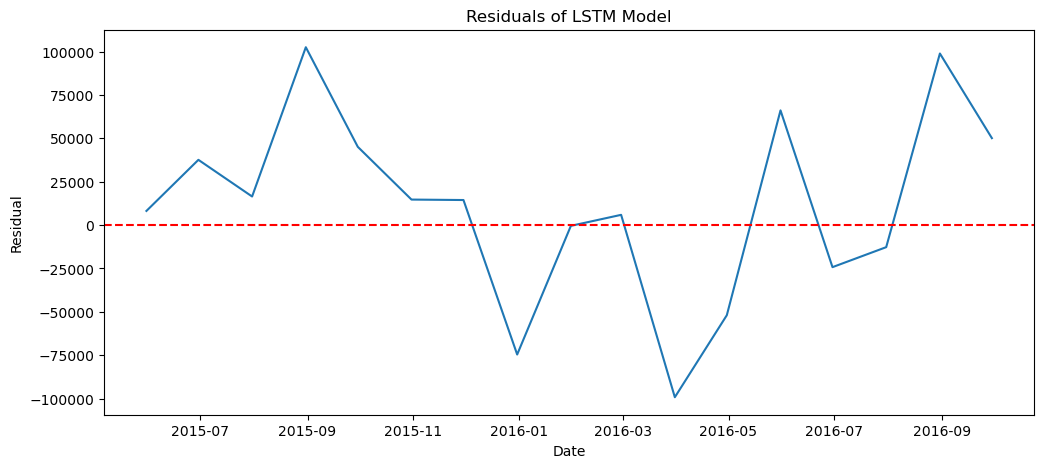

In [21]:
plt.figure(figsize=(12, 5))
plt.plot(test_index, lstm_residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals of LSTM Model")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.show()

# Model Performance

The Long Short-Term Memory (LSTM) network was implemented as a deep learning approach to forecast maritime container throughput. Unlike statistical and tree-based machine learning models, the LSTM architecture is specifically designed to learn sequential patterns from time-series data.

The model was trained using sequences of historical container throughput values, allowing the network to capture temporal dependencies across multiple time steps.

The forecasting performance of the LSTM model was evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE).

The LSTM model was implemented as a deep learning approach to forecast maritime container throughput using sequential time-series data.

The results demonstrate that LSTM is capable of capturing temporal dependencies and producing reasonably accurate forecasts. The model significantly outperforms traditional statistical models such as SARIMA and SARIMAX.

However, the LSTM model does not outperform the XGBoost model in this study. This may be attributed to the limited size of the dataset, which restricts the ability of deep learning models to fully exploit their representational capacity.

Despite this limitation, the LSTM model provides valuable insights into sequential patterns in the container throughput series and serves as an important deep learning benchmark within the forecasting framework.

While the individual models implemented in this study demonstrate varying levels of forecasting performance, each model captures different aspects of the time-series behavior. Statistical models effectively capture trend and seasonality, machine learning models capture nonlinear relationships, and deep learning models capture sequential dependencies. Therefore, the next stage of this research focuses on developing hybrid forecasting models that combine the strengths of multiple approaches to further improve prediction accuracy